In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

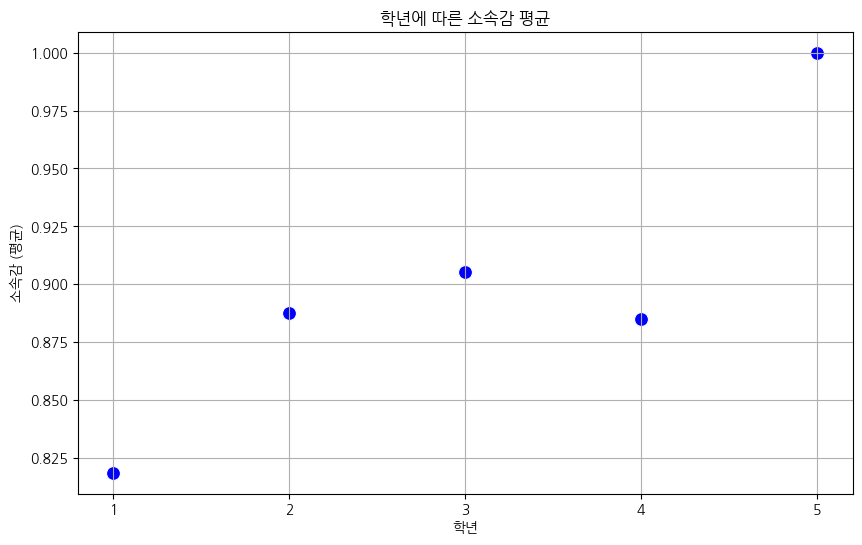

In [ ]:
# 필요한 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font',family='NanumGothic')
plt.rcParams['axes.unicode_minus']=False #

# 데이터 불러오기
file_path = '/content/소속감.xlsx'
data = pd.read_excel(file_path)

# 데이터 전처리
# '학년'을 숫자로 변환
data['학년'] = data['학년'].str.replace('학년', '').astype(int)

# '소속감을 느끼십니까?' 응답을 숫자로 변환 (소속감을 느낀다면 1, 아니면 0)
data['소속감'] = data['귀하는 우리학교에 소속감을 느끼십니까?'].apply(lambda x: 1 if '느낀다' in str(x) else 0)

# 학년별로 소속감 평균 계산
grade_affiliation = data.groupby('학년')['소속감'].mean().reset_index()

# 산점도 그래프 그리기
plt.figure(figsize=(10, 6))
sns.scatterplot(data=grade_affiliation, x='학년', y='소속감', s=100, color='b')
plt.title('학년에 따른 소속감 평균')
plt.xlabel('학년')
plt.ylabel('소속감 (평균)')
plt.xticks(range(1, grade_affiliation['학년'].max() + 1))
plt.grid(True)
plt.show()


In [ ]:
df = pd.read_excel('/content/성공.xlsx', engine='openpyxl')
df

,학년,성공을 위해 시작하고 있다.,성공을 위해 열심히 달려가고 있다.,성공을 이루었다.,성공이 눈앞에 보인다.,실패했다고 생각한다.,잘 모르겠다.,전체
0,1학년,96,106,2,0,4,29,237
1,2학년,88,146,0,5,3,51,293
2,3학년,75,162,1,4,0,32,274
3,4학년,61,131,0,2,3,29,226
4,5학년,2,6,0,0,0,0,8
5,전체,322,551,3,11,10,141,1038


    학년  성공을 위해 시작하고 있다.  성공을 위해 열심히 달려가고 있다.  성공을 이루었다.  성공이 눈앞에 보인다.  \
0  1학년               96                  106          2             0   
1  2학년               88                  146          0             5   
2  3학년               75                  162          1             4   
3  4학년               61                  131          0             2   
4  5학년                2                    6          0             0   

   실패했다고 생각한다.  잘 모르겠다.   전체  
0            4       29  237  
1            3       51  293  
2            0       32  274  
3            3       29  226  
4            0        0    8  


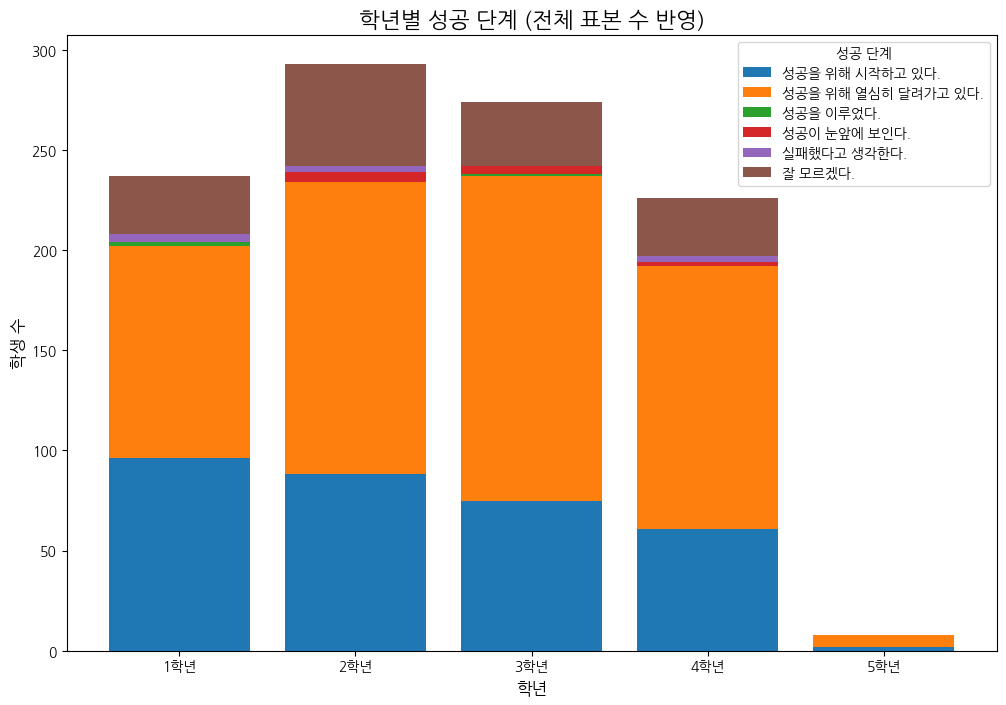

In [ ]:
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('/content/성공.xlsx', engine='openpyxl')
# 전체 데이터 요약
print(df.head())
df = df[df['학년'] != '전체']
# 시각화를 위한 각 학년별 데이터 비교
success_columns = [
    '성공을 위해 시작하고 있다.',
    '성공을 위해 열심히 달려가고 있다.',
    '성공을 이루었다.',
    '성공이 눈앞에 보인다.',
    '실패했다고 생각한다.',
    '잘 모르겠다.'
]
# 누적 막대 그래프 그리기
fig, ax = plt.subplots(figsize=(12, 8))

# 누적값을 저장할 변수 설정
cumulative_values = [0] * len(df)

# 각 항목을 누적하여 막대그래프로 추가
for column in success_columns:
    ax.bar(df['학년'], df[column], bottom=cumulative_values, label=column)
    cumulative_values += df[column]

# 그래프 제목 및 레이블 설정
ax.set_title('학년별 성공 단계', fontsize=16)
ax.set_xlabel('학년', fontsize=12)
ax.set_ylabel('학생 수', fontsize=12)
ax.legend(title='성공 단계')
# 그래프 표시
plt.show()


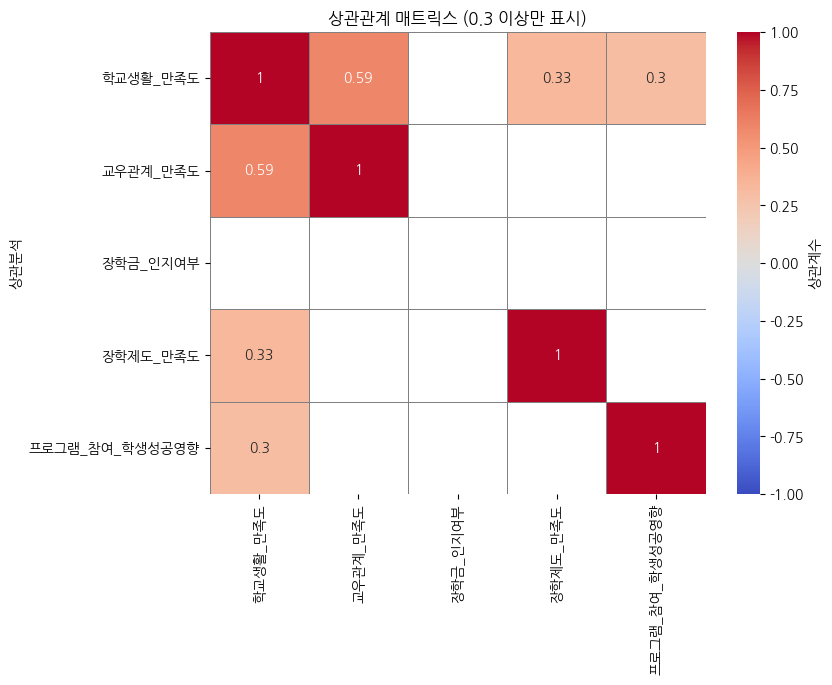

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 엑셀 파일 불러오기
file_path = '/content/상관분석.xlsx'
df = pd.read_excel(file_path, index_col=0)

mask = df.abs() < 0.3
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='gray', cbar_kws={'label': '상관계수'})

plt.title('상관관계 매트릭스')

# 그래프 출력
plt.show()


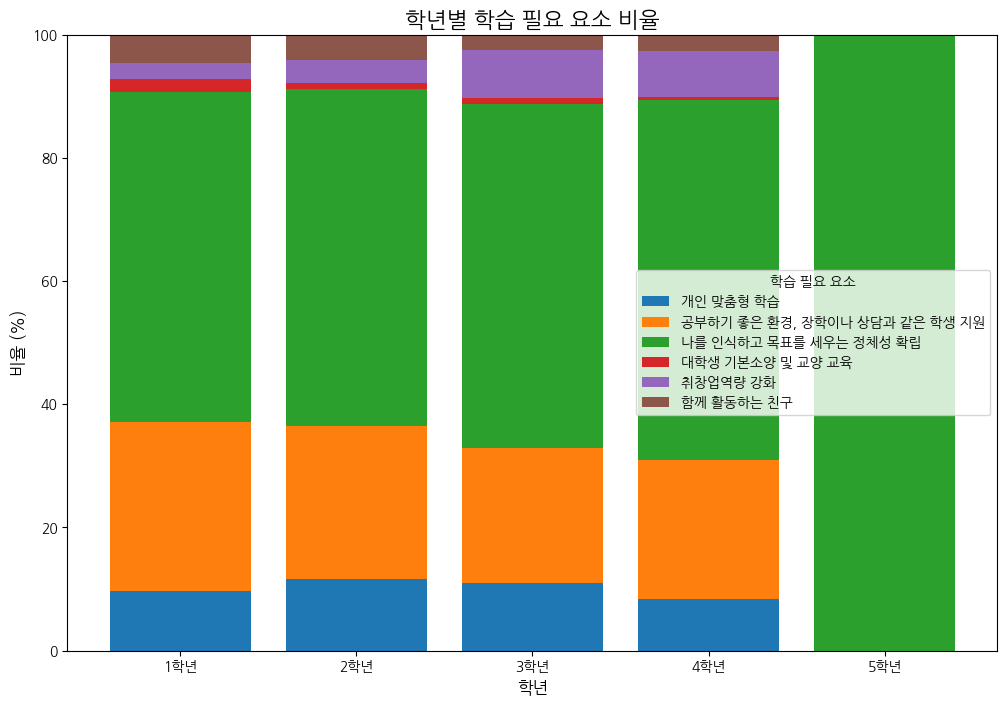

In [ ]:
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('/content/학습.xlsx', engine='openpyxl')
df = df[df['학년'] != '전체']

# 시각화를 위한 각 학년별 데이터 비교
learning_columns = [
    '개인 맞춤형 학습',
    '공부하기 좋은 환경, 장학이나 상담과 같은 학생 지원',
    '나를 인식하고 목표를 세우는 정체성 확립',
    '대학생 기본소양 및 교양 교육',
    '취창업역량 강화',
    '함께 활동하는 친구'
]

# 각 학년별 학습 필요 요소 비율을 계산
for column in learning_columns:
    df[column] = df[column] / df['전체'] * 100

# 누적 막대 그래프 그리기
fig, ax = plt.subplots(figsize=(12, 8))

# 누적값을 저장할 변수 설정
cumulative_values = [0] * len(df)

# 각 항목을 누적하여 막대그래프로 추가
for column in learning_columns:
    ax.bar(df['학년'], df[column], bottom=cumulative_values, label=column)
    cumulative_values += df[column]

# 그래프 제목 및 레이블 설정
ax.set_title('학년별 학습 필요 요소 비율', fontsize=16)
ax.set_xlabel('학년', fontsize=12)
ax.set_ylabel('비율 (%)', fontsize=12)
ax.legend(title='학습 필요 요소')

# 그래프 표시
plt.show()
